# Introduction

Many common probability distributions can be written in the **exponential-family form**

$$ p(x\mid \eta) =  h(x)\exp\left(\eta^T T(x)-A(\eta)\right) $$

where $\eta$ is the **natural parameter**, $T(x)$ is the **sufficient statistic**, and $A(\eta)$ is the **log-partition function**.

This representation is especially useful in Bayesian inference because exponential-family likelihoods often admit **conjugate priors**, for which the posterior belongs to the same family as the prior. As a result, Bayesian updating reduces to simple updates of a small number of parameters.

In this notebook, we derive the general conjugate update and study it through the Bernoulli–Beta and Poisson–Gamma models.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.gaussian import ExponentialFamily

# Exponential Family Representation

## Canonical Form

The canonical exponential family form is
$$ p(x \mid \eta) = h(x) \exp (\eta^T T(x) - A (\eta)) $$
or, equivalently
$$ \boxed{\log p(x \mid \eta) = \log h(x) + \eta^T T(x) - A(\eta)} $$
this form contains four objects:

<center>

| Object    | Name                  | Depends on|  Role |
|:---------:|:---------:            |:---------:|:---------:|
| $T(x)$    | sufficient statistic  | data      | extracting information from data |
| $\eta$    | natural parameter     | model     | coefficient for the information  |
| $h(x)$    | base measure          | data      | leftover term for data           |
| $A(\eta)$ | log-partition         | natural parameter      | normalizes the distribution      |

</center>

All of the objects above can be derived from the likelihood density function. For example, for Bernoulli likelohood
$$ p (x \mid \theta) = \theta^{x} (1 - \theta)^{1-x} $$
the canonical form is
$$ \log p(x \mid \theta) = x \log \frac{\theta}{1 - \theta} + \log (1 - \theta) $$
so from above we can get
* sufficient statistic $T(x) = x$
* natural parameter $\eta = \log \frac{\theta}{1 - \theta}$
* base measure $h(x) = 1$
* log-partition $A(\eta) = \log (1 + e^{\eta})$

## Sufficient Statistic

Let $x_1, x_2, \dots x_n$ be the data and suppose it is iid with
$$ x_i \sim p(x \mid \eta) $$

Then, the likelihood is
$$ p(x_{1:n} \mid \eta) = \prod_{i=1}^n p(x_i \mid \eta) $$
using the canonical form we obtain
$$ 
\begin{aligned}
p(x_{1:n \mid \eta}) &= \prod_{i=1}^n \left[ h(x_i) \exp (\eta^T T(x_i) - A(\eta)) \right] \\
&= \left[ \prod_{i=1}^n h(x_i) \right] \exp \left( \eta^T \sum_{i=1}^n T(x_i) - nA(\eta) \right)
\end{aligned}
$$
Note that the natural parameter $\eta$ interacts with data only via the term
$$ \eta^T \sum_{i=1}^n T(x_i) $$
That is why $T(x)$ is called **sufficient statistic**, basically telling us that it is the only relevant data to estimate the parameter.

For the Bernoulli distribution,
$$ T(x) = x $$
so if we have seen 
$$ x_{1:n} = \left\{ 1, 0, 0, 1, 0, 1, 1 \right\} $$
we only need
$$ \sum_{i=1}^n T(x_i) = 4, \quad n = 7 $$

## Natural Parameter

The natural parameter $\eta$ is not necessary what the initial distribution uses as the parameter. For our Bernoulli example,
$$ \eta = \log \frac{\theta}{1 - \theta}, \quad \theta \in (0, 1), \eta \in \mathbb{R} $$
so the mapping for this case is
$$ (0, 1) \mapsto \mathbb{R} $$

## Base Measure

Base measure $h(x)$ contains whatever is dependent on data but not dependent on natural parameter. In our Bernoulli example we had
$$ \log p(x \mid \theta) = \underbrace{x}_{T(x)} \underbrace{\log \frac{\theta}{1 - \theta}}_{\eta} + \log(1 - \theta) $$
So we did not have any terms depending on $x$ but not on $\eta$, thus,
$$ \log h(x) = 0 \Rightarrow h(x) = 1 $$

## Log-Partition

The log-partition function $A(\eta)$ is a normalization function. It is needed to keep the canonical form a probability density or mass. We originally have
$$ p(x \mid \eta) = h(x) \exp(\eta^T T(x) - A(\eta)) $$
Since it is a probability density, we must have
$$ \int_{\Omega} p(x \mid \eta) dx = 1 $$
or
$$ \int_{\Omega} h(x) \exp(\eta^T T(x) - A(\eta)) dx = 1 $$
since $A(\eta)$ does not depend on $x$,
$$ \exp(-A(\eta)) \int_{\Omega} h(x) \exp(\eta^T T(x)) dx = 1 \Rightarrow A(\eta) = \log \int_{\Omega} h(x) \exp(\eta^T T(x)) dx $$
for continuous random variables, or, equivalently
$$ A(\eta) = \log \sum_{x} h(x) \exp(\eta^T T(x)) $$
for discrete ones.

The expression inside the logarithm is called **partition function** (sometimes normalization constant), that is why we call $A(\eta)$ the **log-partition function**.

## Moments from the Log-Partition Function

A very useful property of the log-partition function is its moments. For an exponential family
$$ p(x \mid \eta) = h(x) \exp(\eta^T T(x) - A(\eta)) $$
the first two derivatives of the log-partition function give
$$ \nabla_{\eta} A(\eta) = \mathbb{E}_{\eta} \left[ T(X) \right] $$
$$ \nabla_{\eta}^2 A(\eta) = \text{Cov}_{\eta} (T(X)) $$

We know that
$$ A(\eta) = \log Z(\eta), \quad Z(\eta) = \int h(x) \exp(\eta^T T(x)) dx $$
now let us find the first moment of $A(\eta)$:
$$ 
\begin{aligned}
\nabla A(\eta) &= \frac{\nabla Z(\eta)}{Z(\eta)} \\
\nabla Z(\eta) &= \int T(x) h(x) \exp(\eta^T T(x)) dx \\
\nabla A(\eta) &= \frac{\int T(x) h(x) \exp(\eta^T T(x)) dx}{Z(\eta)} \\
&= \int T(x) \underbrace{\frac{h(x) \exp(\eta^T T(x))}{Z(\eta)}}_{p(x \mid \eta)} dx \\
&= \int T(x) p(x \mid \eta) dx \\
&= \mathbb{E}_{\eta} [T(X)]
\end{aligned}
$$

### Gaussian Example

Let us find the first and second moment for a univariate Gaussian with known variance for simplicity:
$$ X \sim \mathcal{N}(\mu, \sigma^2) $$
Then, the only ordinary parameter is the mean $\mu$:
$$ p(x \mid \mu) = \frac{1}{\sqrt{2 \pi} \sigma} \exp(-\frac{(x - \mu)^2}{2\sigma^2}) $$
taking the logarithm we obtain
$$ 
\begin{aligned}
\log p(x \mid \mu) &= -\frac{(x - \mu)^2}{2\sigma^2} - \frac{1}{2} \log(2 \pi \sigma^2) \\
&= -\frac{x^2}{2 \sigma^2} + \frac{x \mu}{\sigma^2} - \frac{\mu^2}{2\sigma^2} - \frac{1}{2} \log(2 \pi \sigma^2)
\end{aligned}
$$
from this form we can obtain
* $T(x) = x$
* $\eta = \frac{\mu}{\sigma^2}$
* $\log h(x) = -\frac{x^2}{2 \sigma^2} - \frac{1}{2} \log(2 \pi \sigma^2)$
* $A(\eta) = \frac{\mu^2}{2\sigma^2} = \frac{(\eta \sigma^2)^2}{2\sigma^2} = \frac{\eta^2 \sigma^2}{2}$

Now differentiating $A(\eta)$:
$$ A'(\eta) = \eta \sigma^2 = \mu = \mathbb{E}[X] $$
$$ A''(\eta) = \sigma^2 = \text{Var}(X) $$

# Conjugate Priors

## Generic Conjugate Family

We have worked on the generic canonical form of the likelihood. By Bayes' formula:
$$ p(\eta \mid x) \propto p(x \mid \eta) p(\eta) $$

Conjugate prior is the prior which retains its form after multiplying by likelihood. Normally multiplying a prior to a likelihood gives some unfamiliar distribution as the posterior. So we use conjugate prior to retain the shape of the distribution. For example:
$$ \theta \sim \text{Beta}(a, b),\, X \mid \theta \sim \text{Bernoulli}(\theta) \Rightarrow \theta \mid x_{1:n} \sim \text{Beta}(a', b') $$

Let us fix a likelihood
$$ p(x_{1:n} \mid \eta) = \prod_{i=1}^n h(x_i) \exp(\eta^T T(x_i) - A(\eta)) $$
leave only parameter-dependent values:
$$ p(x \mid \eta) \propto \exp \left( \eta^T \sum_{i=1}^n T(x_i) - nA(\eta) \right) $$
In this form the natural parameter $\eta$ appears only in two ways:
$$ \eta \text{ and } A(\eta) $$
we want to have something similar as the prior to retain the form in posterior. So let us have
$$ p(\eta \mid \alpha, \nu) \propto \exp (\alpha^T \eta - \nu A(\eta)) $$
It is also possible to normalize the distribution by adding another log-partition function
$$ p(\eta \mid \alpha, \nu) = \exp(\alpha^T \eta - \nu A(\eta) - B(\alpha, \nu)) $$

Note that the conjugate prior itself can be seen as an exponential family. Let us have
$$ p(\eta \mid \alpha, \nu) = \exp(\alpha^T \eta - \nu A(\eta) - B(\alpha, \nu)) $$
then, under 
$$ \eta_c = \begin{bmatrix} \alpha \\ \nu \end{bmatrix}, \quad T_c(\eta) = \begin{bmatrix} \eta \\ -A(\eta) \end{bmatrix} $$
we have
$$ p(\eta \mid \eta_c) = \exp \left( \eta_c^T T_c(\eta) - B(\alpha, \nu) \right) $$
which is exactly the form of the exponential family we have discussed before.

## Posterior Derivation

Bayes' rule gives us
$$ 
\begin{aligned}
p(\eta \mid x_{1:n}) & \propto p(x_{1:n} \mid \eta) p(\eta \mid \alpha, \nu) \\
& \propto \left( \exp \left( \eta^T \sum_{i=1}^n T(x_i) - nA(\eta) \right) \right) \left( \exp (\alpha^T \eta - \nu A(\eta)) \right) \\
& \propto \exp \left( \left( \sum_{i=1}^n T(x_i) + \alpha \right)^T \eta - (n + \nu) A(\eta) \right)
\end{aligned}
$$

## Generic Update Rule

So, the posterior has exactly the same form as the prior, but with different parameters
$$ \boxed{\alpha' = \alpha + \sum_{i=1}^n T(x_i), \quad \nu' = \nu + n} $$

That is how we generally update the posterior.

### Interpretation

The model above can be seen as
* $\nu$ can be interpreted as an effective prior sample size, while $\alpha$ represents corresponding accumulated prior sufficient statistics.
* then we have discovered another $n$ samples with $\sum_{i=1}^n T(x_i)$ sufficient statistic
* the posterior then has in total $\nu + n$ samples and $\alpha + \sum_{i=1}^n T(x_i)$ sufficient statistic

So, basically,
$$ \boxed{\text{posterior information} = \text{prior information} + \text{data information}} $$

# Implementation

## ExponentialFamily

The `ExponentialFamily` class was implemented in the source `gaussian.py` code using the Abstract Base Class (abc). To initialize the exponential family we need:

* log base measure $\log h(x)$
* sufficient statistic $T(x)$
* log-partition $A(\eta)$
* conjugate log-partition $B(\alpha, \nu)$

Natural parameter $\eta$ is not provided to the method since it is distribution-specific. Instead we use it as an input to some of the functions.

Before discussing the implementation details let us recall the variable dimensionalities

<center>

| Object | $x$ | $T(x)$ | $h(x)$ | $\eta$ | $A(\eta)$ | $\alpha$ | $\nu$ | $B(\alpha, \nu)$ |
|:------:|:---:|:------:|:------:|:------:|:---------:|:--------:|:-----:|:----------------:|
| Dimension | $\mathbb{R}^d$ | $\mathbb{R}^k$ | $\mathbb{R}_+$ | $\mathbb{R}^k$ | $\mathbb{R}$ | $\mathbb{R}^k$ | $\mathbb{R}$ | $\mathbb{R}$ |

</center>

Now let us discuss two generic functions not depending on specific exponential family.

### log_pdf

The log-pdf function is calculating the log-likelihood density of the family at some point $x \in \mathbb{R}^d$. The mathematical formulation is
$$ \log p(x \mid \eta) = \log h(x) + \eta^T T(x) - A(\eta) $$

The `linear_term` below is just a calculation of $\eta^T T(x)$. Matrix operations are there to support vector-valued sufficient statistics and batched inputs.

```python
def log_pdf(self, x):
    linear_term = (
        self.sufficient_statistics(x)[..., None, :] @ natural_parameters[..., None]
    )[..., 0, 0]
    
    return (
        self.log_base_measure(x)
        + linear_term
        - self.log_partition(natural_parameters)
    )
```

### posterior_parameters

The `posterior_parameters` function is used to obtain the posterior using prior and data. As we have derived,
$$ \alpha' = \alpha + \sum_{i=1}^n T(x_i), \quad \nu' = \nu + n $$

In the implemented method we assume that parameters are given as a vector
$$ \begin{bmatrix} \alpha \\ \nu \end{bmatrix} \in \mathbb{R}^{k+1} $$

Thus, to obtain the parameters we split the vector and perform the parameter update.

```python
def posterior_parameters(self, prior_natural_parameters, data):
    prior_alpha, prior_nu = (       # Splitting the parameters
        prior_natural_parameters[:-1],
        prior_natural_parameters[-1],
    )
    sufficient_statistics = self.sufficient_statistics(data)    # Calculating T(x)
    n = sufficient_statistics[..., 0].size

    expected_sufficient_statistics = jnp.sum(
        sufficient_statistics, axis=tuple(range(sufficient_statistics.ndim - 1))    # Summing up the sufficient statistics
    )

    return jnp.append(prior_alpha + expected_sufficient_statistics, prior_nu + n)   # Updated parameters
```

## ConjugateFamily

`ExponentialFamily` class is later used as a base class for the `ConjugateFamily` class since it also can be seen as an exponential family as discussed before. It uses an exponential family as the likelihood and, thus, can use its properties to get the posterior. We have defined the conjugate sufficient statistic as
$$ T_c(\eta) = \begin{bmatrix} \eta \\ -A(\eta) \end{bmatrix} \in \mathbb{R}^{k+1} $$
and conjugate natural parameters as
$$ \eta_c = \begin{bmatrix} \alpha \\ \nu \end{bmatrix} \in \mathbb{R}^{k+1} $$

Then, the implementation has three most important functions:
```python
def sufficient_statistics(self, eta)
    return jnp.append(eta, -self._likelihood.log_partition(eta))    # T_c(eta) = [eta, -A(eta)]

def log_partition(self, natural_parameters)
    alpha, nu = natural_parameters[:-1], natural_parameters[-1]
    return self._likelihood.conjugate_log_partition(alpha, nu)      # B(alpha, nu); initialized with ExponentialFamily

def unnormalized_log_pdf(self, eta, natural_parameters)
    return self.sufficient_statistics(eta) @ jnp.asarray(natural_parameters)  # Derived before
```

# Bernoulli-Beta Conjugacy

## Bernoulli Exponential Family

For Bernoulli log-likelihood we have already derived
$$ \log p (x \mid \eta) = \eta T(x) - A(\eta) $$
with
* $\eta = \log \frac{\theta}{1 - \theta}$
* $A(\eta) = \log (1 + e^{\eta})$
* $T(x) = x$
* $\log h(x) = 0$

## Beta Prior for Bernoulli EF


For the Bernoulli likelihood, the conjugate prior, then, should be
$$ 
\begin{aligned}
p_{\eta}(\eta \mid \alpha, \nu) & \propto \exp \left( \alpha \eta - \nu A(\eta) \right) \\
&= \exp \left( \alpha \log \frac{\theta}{1 - \theta} - \nu \log \left( 1 + \exp \left( \log \frac{\theta}{1 - \theta} \right) \right) \right) \\
&= \exp \left( \alpha \log \frac{\theta}{1 - \theta} - \nu \log \frac{1}{1 - \theta} \right) \\
&= \left( \frac{\theta}{1 - \theta} \right)^{\alpha} \left( \frac{1}{1 - \theta} \right)^{-\nu} \\
&= \theta^{\alpha} (1 - \theta)^{\nu - \alpha} \\
p_{\theta} (\theta \mid \alpha, \nu) & \propto p_{\eta} (\eta(\theta) \mid \alpha, \nu) \underbrace{\Bigm| \frac{d \eta}{d \theta} \Bigm|}_{\theta^{-1} (1 - \theta)^{-1}} \\
&= \theta^{\alpha} (1 - \theta)^{\nu - \alpha} \theta^{-1} (1 - \theta)^{-1} \\
&= \theta^{\alpha - 1} (1 - \theta)^{\nu - \alpha - 1}
\end{aligned}
$$

Thus,
$$ \theta \sim \text{Beta}(\alpha, \nu - \alpha) $$

So that is how we obtained a Beta prior to the Bernoulli likelihood.

## Conjugate Log-Partition

The only function left to initialize the Bernoulli exponential family is conjugate log-partition function $B(\alpha, \nu)$. It should satisfy
$$ B(\alpha, \nu) = \log \int_{\Omega} \exp (\alpha^T \eta - \nu A(\eta)) d \eta $$
so that the pdf normalizes.

Since we already derived the Beta prior, we know that the normalization constant is Euler's Beta function:
$$ \Beta(\alpha, \nu - \alpha) = \frac{\Gamma(\alpha) \Gamma(\nu - \alpha)}{\Gamma(\nu)}  $$

Thus, the conjugate log-partition is
$$ B(\alpha, \nu) = \log \Gamma(\alpha) + \log \Gamma (\nu - \alpha) - \log \Gamma (\nu) $$

## Example: Unfair Coin Toss

Let us suppose we toss an unfair coin with unknown probability of heads. The likelihood of tossing a head is Bernoulli given the probability $\theta$:
$$ p(x \mid \theta) = \theta^{x} (1 - \theta)^{1 - x} $$
Let us first suppose that the parameter $\theta$ is distributed uniformly, i.e.
$$ \theta \sim U[0, 1] = \text{Beta}(1, 1) $$
This is our prior: Beta distribution with $\alpha = 1, \nu = 2$.

We have already derived all of the needed functions, so let us implement the Bernoulli-Beta conjugate family.

In [3]:
class BernoulliEF(ExponentialFamily):
    def log_base_measure(self, x):
        return jnp.zeros_like(x)

    def sufficient_statistics(self, x):
        x = jnp.asarray(x)
        return x

    def log_partition(self, natural_parameters):
        natural_parameters = jnp.asarray(natural_parameters)
        return jnp.log(1 + jnp.exp(natural_parameters))

    def conjugate_log_partition(self, alpha, nu):
        from jax.scipy.special import gammaln

        alpha = jnp.asarray(alpha)
        nu = jnp.asarray(nu)

        return gammaln(alpha) + gammaln(nu - alpha) - gammaln(nu)

For simplicity let us also implement functions that will convert the parameters of the beta distribution $(a, b)$ into conjugate parameters $(\alpha, \nu)$ and vice versa. We have already defined
$$ \theta \sim \text{Beta}(\underbrace{\alpha}_{=a}, \underbrace{\nu - \alpha}_{=b}) $$
So the functions should be
$$ (\alpha, \nu) \leftrightarrow (a, b) $$

In [4]:
def conjugate_params_to_beta(params):
    alpha = float(params[0])
    nu = float(params[1])

    return (alpha, nu - alpha)

def beta_to_conjugate_params(a, b):
    return jnp.array([a, a + b])

In [5]:
bernoulli = BernoulliEF()
conjugate = bernoulli.conjugate_prior()

a_prior, b_prior = (1.0, 1.0)  # Uniform distribution a=b=1
prior_parameters = beta_to_conjugate_params(a_prior, b_prior)

Now suppose we toss the coin several times and obtain the following results:
$$ x = (1, 0, 0, 1, 1, 1, 1, 0) $$
then, 
$$ \sum_{i=1}^n T(x_i) = 5, \quad n = 8 $$
and the updated parameters are:
$$ \alpha' = \alpha + \sum_{i=1}^n T(x_i) = 1 + 5 = 6, \quad \nu' = \nu + n = 2 + 8 = 10 $$

So the PDF of prior is
$$ p(\theta) = \Beta(1, 1) $$

PDF of posterior is
$$ p(\theta \mid D) = \Beta(1 + 5, 1 + 3) $$

And the PMF of likelihood is
$$ p(D \mid \theta) = \theta^{5} (1 - \theta)^{3} $$

In [6]:
data = jnp.array([1, 0, 0, 1, 1, 1, 1, 0])[..., None]

posterior_parameters = bernoulli.posterior_parameters(prior_parameters, data)

posterior_parameters

Array([ 6., 10.], dtype=float64)

Text(0.5, 1.0, 'Posterior')

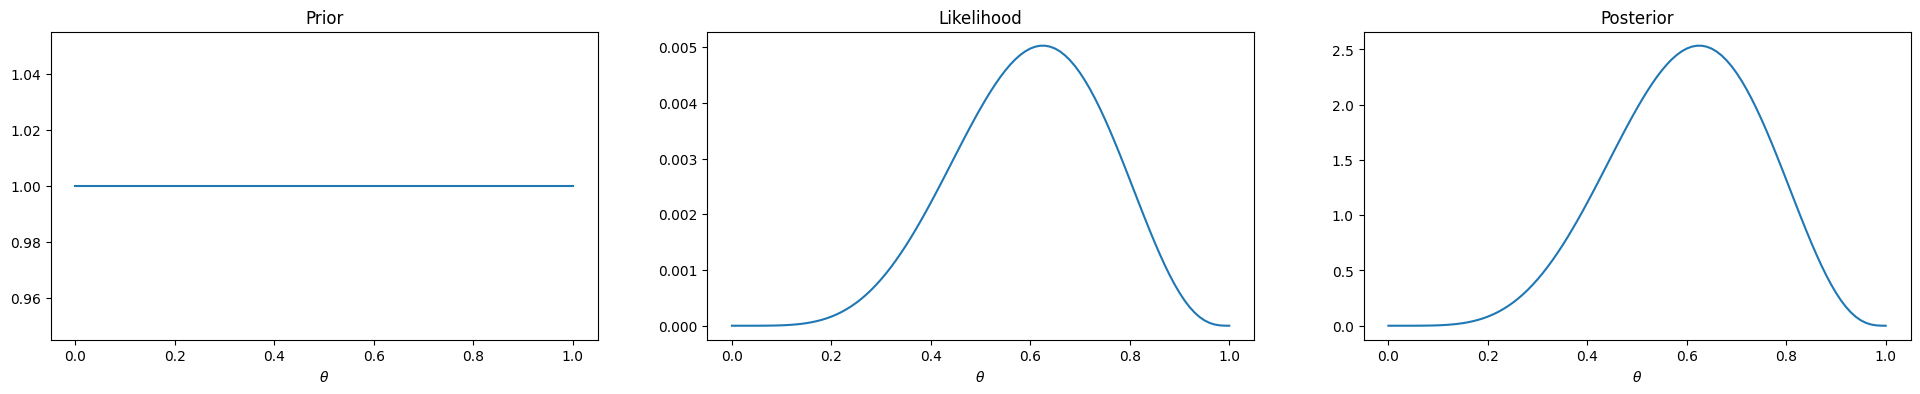

In [7]:
a_posterior, b_posterior = conjugate_params_to_beta(posterior_parameters)
H_count = data.sum()
T_count = (1 - data).sum()

theta_grid = jnp.arange(0, 1.01, 0.01)

prior_pdf = jax.scipy.stats.beta.pdf(theta_grid, a_prior, b_prior)
likelihood_curve = theta_grid**H_count * (1 - theta_grid)**T_count
posterior_pdf = jax.scipy.stats.beta.pdf(theta_grid, a_posterior, b_posterior)

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 4))

axes[0].plot(theta_grid, prior_pdf)
axes[0].set_xlabel(r"$\theta$")
axes[0].set_title("Prior")

axes[1].plot(theta_grid, likelihood_curve)
axes[1].set_xlabel(r"$\theta$")
axes[1].set_title("Likelihood")

axes[2].plot(theta_grid, posterior_pdf)
axes[2].set_xlabel(r"$\theta$")
axes[2].set_title("Posterior")

From here we can predict the probability of the next toss being a head:
$$ 
\begin{aligned}
\mathbb{P}(X_{\text{new}} = 1 \mid D) &= \int_{0}^{1} \underbrace{\mathbb{P}(X_{\text{new}} = 1 \mid \theta)}_{=\theta} p(\theta \mid D) d \theta \\
&= \int_0^1 \theta p(\theta \mid D) d\theta \\
&= \mathbb{E} \left[ \theta \mid D \right] \\
&= \frac{a'}{a' + b'} \\
\end{aligned}
$$

Which can also be approximated as
$$ \mathbb{P}(X_{\text{new}} = 1 \mid D) = \sum_i \theta_i p(\theta_i \mid D) \Delta_{\theta} $$
where $\Delta_{\theta}$ is the Riemann mesh.

And the predictive variance is
$$ 
\begin{aligned}
\text{Var}(X_{\text{new}} \mid D) &= p(1 - p) \\
&= \left( \frac{a'}{a' + b'} \right)  \left( \frac{b'}{a' + b'} \right)
\end{aligned}
$$

In [8]:
p = jnp.sum(posterior_pdf * theta_grid) * 0.01

print(f"Predictive mean = {p:.3f}")
print(f"Predictive variance = {p*(1-p):.3f}")

Predictive mean = 0.600
Predictive variance = 0.240


Now let us suppose we toss the coin several more times and obtain the following data:
$$ x = (0, 1, 0, 1, 1, 1) $$
so we have
$$ \sum_{i=1}^n T(x_i) = 4, \quad n = 6 $$

If we use the results of our first experiment as the new prior we can obtain new posterior.

In [9]:
a_prior, b_prior = a_posterior, b_posterior
prior_parameters = posterior_parameters

data = jnp.array([0, 1, 0, 1, 1, 1])[..., None]

posterior_parameters = bernoulli.posterior_parameters(prior_parameters, data)

prior_parameters, posterior_parameters

(Array([ 6., 10.], dtype=float64), Array([10., 16.], dtype=float64))

Text(0.5, 1.0, 'Posterior')

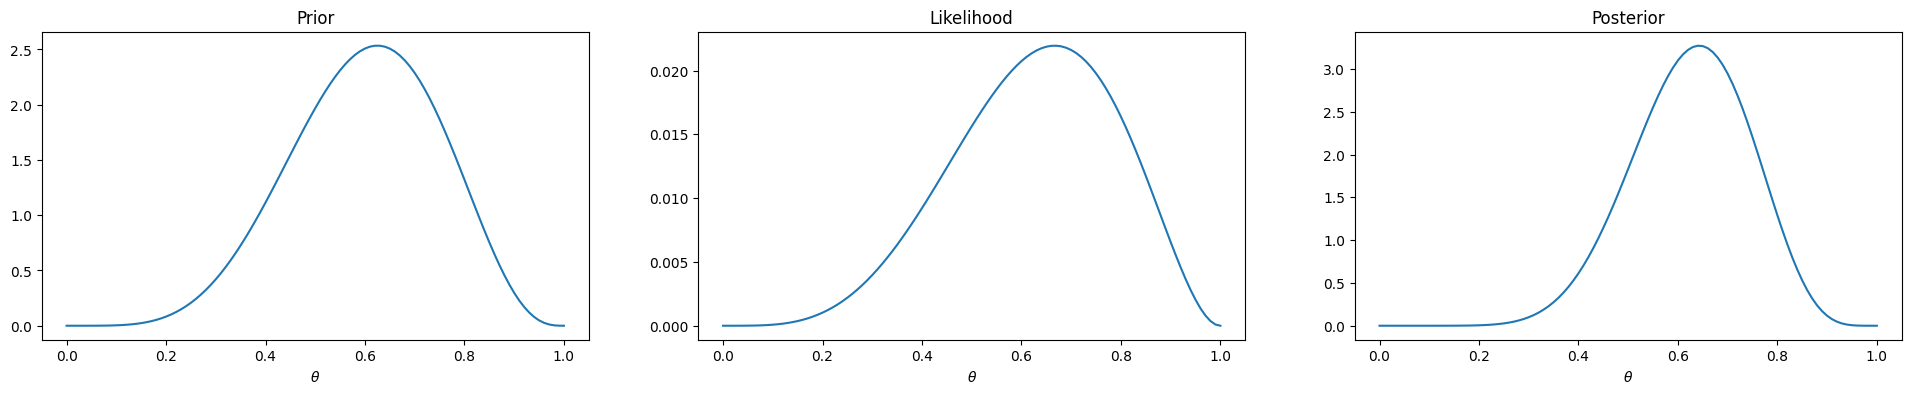

In [10]:
a_posterior, b_posterior = conjugate_params_to_beta(posterior_parameters)
H_count = data.sum()
T_count = (1 - data).sum()

theta_grid = jnp.arange(0, 1.01, 0.01)

prior_pdf = jax.scipy.stats.beta.pdf(theta_grid, a_prior, b_prior)
likelihood_curve = theta_grid**H_count * (1 - theta_grid)**T_count
posterior_pdf = jax.scipy.stats.beta.pdf(theta_grid, a_posterior, b_posterior)

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 4))

axes[0].plot(theta_grid, prior_pdf)
axes[0].set_xlabel(r"$\theta$")
axes[0].set_title("Prior")

axes[1].plot(theta_grid, likelihood_curve)
axes[1].set_xlabel(r"$\theta$")
axes[1].set_title("Likelihood")

axes[2].plot(theta_grid, posterior_pdf)
axes[2].set_xlabel(r"$\theta$")
axes[2].set_title("Posterior")

In [11]:
p = jnp.sum(posterior_pdf * theta_grid) * 0.01

print(f"Predictive mean = {p:.3f}")
print(f"Predictive variance = {p*(1-p):.3f}")

Predictive mean = 0.625
Predictive variance = 0.234


# Poisson-Gamma Conjugacy

## Poisson Exponential Family

Now let us consider Poisson Exponential Family. The pdf of Poisson distribution is
$$ p(x \mid \lambda) = \frac{\lambda^x e^{-\lambda}}{x!} $$

We want to bring it to the canonical representation
$$ \log p(x \mid \lambda) = \log h(x) + \eta^T T(x) - A(\eta) $$

Taking the logarithm
$$ \log p(x \mid \lambda) = x \log \lambda - \lambda - \log x! $$
from here we can clearly see
* log-base measure $\log h(x) = -\log x!$
* sufficient statistic $T(x) = x$
* natural parameter $\eta = \log \lambda$
* log-partition $A(\eta) = e^{\eta}$

## Gamma Prior for Poisson EF

Now, given the canonical representation we can derive the prior
$$ 
\begin{aligned}
p_{\eta} (\eta \mid \alpha, \nu) & \propto \exp \left( \eta \alpha - \nu A(\eta) \right) \\
&= \exp \left( \alpha \log \lambda - \nu \lambda \right) \\
&= \lambda^{\alpha} e^{-\nu \lambda}\\
p_{\lambda} (\lambda \mid \alpha, \nu) &= p_{\eta} (\eta \mid \alpha, \nu) \Bigm| \frac{d \eta}{d \lambda} \Bigm| \\
& \propto \lambda^{\alpha} e^{-\nu \lambda} \frac{1}{\lambda} \\
&= \lambda^{\alpha - 1} e^{-\nu \lambda}
\end{aligned}
$$
Thus,
$$ \lambda \sim \text{Gamma}(\alpha, \nu) $$
with shape $\alpha > 0$ and rate $\nu > 0$.

## Conjugate Log-Partition

Since we want a normalized distribution, we need
$$ B(\alpha, \nu) = \log \int_{\Omega} \exp(\eta \alpha - \nu A(\eta)) d \eta $$
We have already discovered that the prior is distributed according to the Gamma distribution, which has a normalization constant of
$$ \frac{\nu^{\alpha}}{\Gamma(\alpha)} $$
Thus, our log-partition is
$$ B(\alpha, \nu) = \log \Gamma(\alpha) - \alpha \log \nu $$

## Example: Call Center

Let us imagine a call center that has recieved some number of calls within some period of time. Let us suppose some prior frequency of calls as 2 calls per minute. Then, our prior is
$$ \lambda \sim \text{Gamma}(2, 1) $$

In [12]:
class PoissonEF(ExponentialFamily):
    def sufficient_statistics(self, x):
        x = jnp.asarray(x)

        return x

    def log_base_measure(self, x):
        x = jnp.asarray(x)

        return -jax.scipy.special.gammaln(x + 1)

    def log_partition(self, natural_parameters):
        natural_parameters = jnp.asarray(natural_parameters)

        return jnp.exp(natural_parameters)

    def conjugate_log_partition(self, alpha, nu):
        alpha = jnp.asarray(alpha)
        nu = jnp.asarray(nu)

        if alpha.ndim > 0 and alpha.shape[-1] == 1:
            alpha = jnp.squeeze(alpha, axis=-1)
            
        return jax.scipy.special.gammaln(alpha) - alpha * jnp.log(nu)

In [13]:
def conjugate_params_to_gamma(params):
    alpha = float(params[0])
    nu = float(params[1])

    return (alpha, nu)

def gamma_to_conjugate_params(alpha, nu):
    return jnp.array([alpha, nu])

In [14]:
poisson = PoissonEF()

alpha_prior = 2.0
nu_prior = 1
prior_parameters = gamma_to_conjugate_params(alpha_prior, nu_prior)

Now let us say we recorded the number of calls each minute for the last 10 minutes and obtained
$$ x = (2, 3, 4, 1, 0, 5, 3, 2, 1, 2) $$

Then, we can have
$$ \sum_{i=1}^{n} T(x_i) = 23, \quad n = 10 $$

In [15]:
data = jnp.asarray([2, 3, 4, 1, 0, 5, 3, 2, 1, 2])[..., None]

posterior_parameters = poisson.posterior_parameters(prior_parameters, data)
posterior_parameters

Array([25., 11.], dtype=float64)

As expected,
$$ \alpha' = \alpha + \sum_{i=1}^n T(x_i) = 2 + 23 = 25, \quad \nu' = \nu + n = 1 + 10 = 11 $$

Text(0.5, 1.0, 'Posterior')

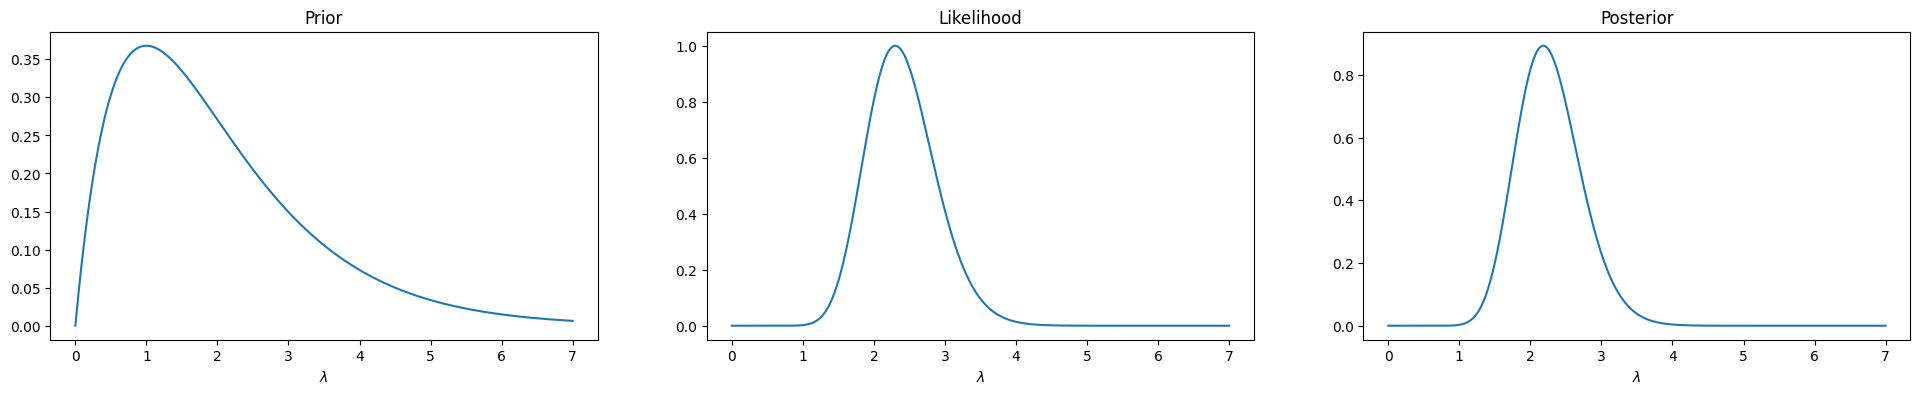

In [16]:
alpha_posterior, nu_posterior = conjugate_params_to_gamma(posterior_parameters)
rate_data = data.mean()

lambda_grid = jnp.arange(0, 7.01, 0.01)

prior_pdf = jax.scipy.stats.gamma.pdf(lambda_grid, alpha_prior, scale = 1/nu_prior)
log_likelihood = (
    data.sum() * jnp.log(lambda_grid + 1e-12)
    - data.size * lambda_grid
)

likelihood_curve = jnp.exp(
    log_likelihood - log_likelihood.max() #for numerical stability
)
posterior_pdf = jax.scipy.stats.gamma.pdf(lambda_grid, alpha_posterior, scale = 1/nu_posterior)

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 4))

axes[0].plot(lambda_grid, prior_pdf)
axes[0].set_xlabel(r"$\lambda$")
axes[0].set_title("Prior")

axes[1].plot(lambda_grid, likelihood_curve)
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_title("Likelihood")

axes[2].plot(lambda_grid, posterior_pdf)
axes[2].set_xlabel(r"$\lambda$")
axes[2].set_title("Posterior")

Now we have a posterior distribution
$$ \lambda \mid D \sim \text{Gamma}(\alpha', \nu') $$

With the posterior mean rate of
$$ \mathbb{E} [\lambda \mid D] = \frac{\alpha'}{\nu'} $$
and posterior variance of
$$ \text{Var}(\lambda \mid D) = \frac{\alpha'}{(\nu')^2} $$

In [17]:
print(f"Posterior mean = {alpha_posterior / nu_posterior:.3f}")
print(f"Posterior variance = {alpha_posterior / nu_posterior**2:.3f}")

Posterior mean = 2.273
Posterior variance = 0.207


## Negative Binomial Predictive Distribution

We have obtained the posterior distribution of the rate
$$ \lambda \mid D \sim \text{Gamma}(\alpha', \nu') $$

Now let us obtain the predictive distribution over the number of calls for the next minute
$$ \mathbb{P} (Y = k \mid D) $$

Using the Law of Total Probability
$$ 
\begin{aligned}
\mathbb{P} (Y = k \mid D) &= \int_0^{\infty} \mathbb{P}(Y = k \mid \lambda) p(\lambda \mid D) d \lambda \\
&= \int_0^{\infty} \underbrace{\frac{\lambda^k e^{-\lambda}}{k!}}_{\mathbb{P}(Y=k \mid \lambda)} \underbrace{\frac{(\nu')^{\alpha'}}{\Gamma(\alpha')} \lambda^{\alpha' - 1} e^{-\nu' \lambda}}_{p(\lambda \mid D)} d\lambda
\end{aligned}$$

Since
* $k! = \Gamma(k+1)$
* $\int_0^{\infty} \lambda^{a-1} e^{-b \lambda} d\lambda = \frac{\Gamma(a)}{b^{a}}$

$$
\begin{aligned}
\mathbb{P} (Y = k \mid D) &= \int_0^{\infty} \frac{\lambda^k e^{-\lambda}}{k!} \frac{(\nu')^{\alpha'}}{\Gamma(\alpha')} \lambda^{\alpha' - 1} e^{-\nu' \lambda} d\lambda \\
&= \int_0^{\infty} \frac{\lambda^k e^{-\lambda}}{\Gamma(k+1)} \frac{(\nu')^{\alpha'}}{\Gamma(\alpha')} \lambda^{\alpha' -1} e^{-\nu' \lambda} d\lambda \\
&= \frac{(\nu')^{\alpha'}}{\Gamma(k+1) \Gamma(\alpha')} \int_0^{\infty} \lambda^k e^{-\lambda} \lambda^{\alpha' - 1} e^{-\nu' \lambda} d\lambda \\
&= \frac{(\nu')^{\alpha'}}{\Gamma(k+1) \Gamma(\alpha')} \int_0^{\infty} \lambda^{k + \alpha' - 1} e^{-\lambda (\nu' + 1)} d\lambda \\
&= \frac{(\nu')^{\alpha'}}{\Gamma(k+1) \Gamma(\alpha')} \frac{\Gamma(k + \alpha')}{(\nu' + 1)^{k + \alpha'}}
\end{aligned}
$$

Now, since
$$ \frac{\Gamma(k + \alpha')}{\Gamma(k+1) \Gamma(\alpha')} = \binom{k + \alpha' - 1}{k} $$

we can write
$$
\begin{aligned}
\mathbb{P} (Y = k \mid D) &= \int_0^{\infty} \frac{\lambda^k e^{-\lambda}}{k!} \frac{(\nu')^{\alpha'}}{\Gamma(\alpha')} \lambda^{\alpha' - 1} e^{-\nu' \lambda} d\lambda \\
&= \frac{(\nu')^{\alpha'}}{\Gamma(k+1) \Gamma(\alpha')} \frac{\Gamma(k + \alpha')}{(\nu' + 1)^{k + \alpha'}} \\
&= \binom{k + \alpha' - 1}{k} \frac{(\nu')^{\alpha'}}{(\nu' + 1)^{k + \alpha'}} \\
&= \binom{k + \alpha' - 1}{k} \left( \frac{1}{\nu' + 1} \right)^k \left( \frac{\nu'}{\nu' + 1} \right)^{\alpha'}
\end{aligned}
$$

Which is a **Negative Binomial Distribution** with
$$ p = \frac{\nu'}{\nu' + 1}, \quad r = \alpha' $$

Thus, we have obtained
$$ Y \sim \text{NB} \left( \alpha', \frac{\nu'}{\nu' + 1} \right) $$

Text(0.5, 1.0, 'PMF of a Predictive Distribution')

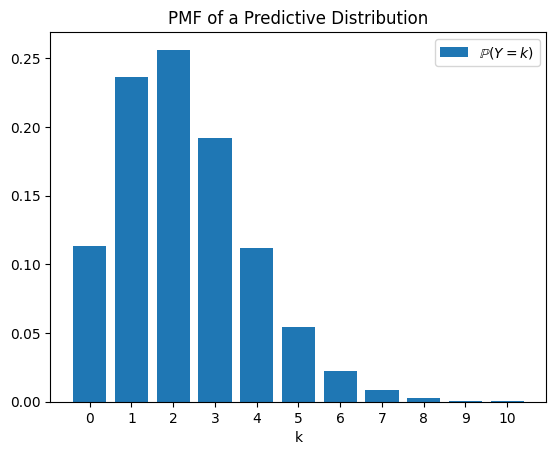

In [18]:
def nb_pmf(k, r, p):
    return jnp.exp(jax.scipy.special.gammaln(k + r) - 
                   jax.scipy.special.gammaln(k + 1) - 
                   jax.scipy.special.gammaln(r) + 
                   r * jnp.log(p) + 
                   k * jnp.log1p(-p))

r = alpha_posterior
p = nu_posterior / (nu_posterior + 1)

k = jnp.arange(0, 11, 1)

plt.bar(k, nb_pmf(k, r, p), label = r'$\mathbb{P}(Y = k)$')
plt.xticks(k)
plt.xlabel(r'k')
plt.legend()
plt.title('PMF of a Predictive Distribution')

# What Exponential Families Buy Us

## Sufficient-Statistic Compression

For iid observations from an exponential family,

$$
p(x_{1:n}\mid\eta)
\propto
\exp\left(
\eta^T\sum_{i=1}^n T(x_i)-nA(\eta)
\right).
$$

The data affect inference about $\eta$ only through

$$
\sum_{i=1}^n T(x_i)
$$

and the number of observations $n$. Thus, the full dataset can be replaced by a fixed-dimensional sufficient statistic without losing information about the parameter within the assumed model.

For example, for Bernoulli data it is sufficient to store the number of successes and the total number of observations.

## Sequential Bayesian Updating

Conjugate exponential-family models allow posterior parameters to be updated incrementally:

$$
\alpha'=\alpha+\sum_{i=1}^n T(x_i),
\qquad
\nu'=\nu+n.
$$

The posterior after one batch of observations can be used directly as the prior for the next batch. Therefore, previous observations do not need to be stored explicitly once their sufficient statistics have been accumulated.

## Analytic Inference

For conjugate likelihood-prior pairs, the posterior distribution is available in closed form. Bayesian inference then reduces to updating the parameters of a known distribution.

Examples considered in this notebook are

$$
\text{Bernoulli likelihood}
\quad\leftrightarrow\quad
\text{Beta prior},
$$

and

$$
\text{Poisson likelihood}
\quad\leftrightarrow\quad
\text{Gamma prior}.
$$

This avoids numerical posterior approximations such as MCMC or variational inference for these models.

# Limitations

The exponential-family and conjugate framework has several limitations.

* Not every probability distribution belongs to a useful finite-dimensional exponential family.
* Conjugacy depends on the particular likelihood-prior pair. An arbitrary prior generally does not produce an analytic posterior.
* More complex models, such as hierarchical, nonlinear, or mixture models, often lose conjugacy even when some individual components belong to exponential families.
* Sufficient-statistic compression preserves information about the parameters under the assumed model, not necessarily information required for other tasks.
* Analytic tractability usually comes from stronger modeling assumptions and may be less flexible than numerical Bayesian methods.

# Conclusion

Exponential families provide a common representation for many probability distributions:

$$
p(x\mid\eta)
=
h(x)\exp\left(
\eta^T T(x)-A(\eta)
\right).
$$

Their structure gives sufficient statistics, simple expressions for moments through the log-partition function, and a generic form for conjugate priors.

For conjugate models, posterior inference reduces to the update

$$
\alpha'=\alpha+\sum_i T(x_i),
\qquad
\nu'=\nu+n.
$$

The Bernoulli-Beta and Poisson-Gamma models are concrete examples of this general construction. In the Poisson-Gamma case, integrating out the uncertain rate also produces the Negative Binomial posterior predictive distribution.
